# Querying SQL with Python

Connecting to the **Chinook** sample database via Python's
built-in `sqlite3` library, running SQL queries to answer
three business questions, and loading results into Pandas
DataFrames.

**Project:** https://roadmap.sh/projects/querying-sql-python

In [1]:
# Author:      Wajid Ali Saleem Chaudhry
# Description: SQL queries on Chinook DB via sqlite3 and Pandas.

import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

# --- Setup ---

Path("outputs").mkdir(exist_ok=True)

DB_PATH = "Chinook_Sqlite.sqlite"
conn = sqlite3.connect(DB_PATH)
print("Connected to Chinook database.")

Connected to Chinook database.


## Database Schema

Chinook models a digital music store. Key tables used here:

| Table | Description |
|---|---|
| `Track` | Song catalogue |
| `Album` | Album catalogue |
| `Artist` | Artist catalogue |
| `InvoiceLine` | Line items per invoice |
| `Invoice` | Customer invoices |
| `Customer` | Customer records |
| `Employee` | Staff records |

In [2]:
# --- Schema Exploration ---

# List every table in the database
q_tables = """
    SELECT name AS TableName
    FROM   sqlite_master
    WHERE  type = 'table'
    ORDER  BY name;
"""
df_tables = pd.read_sql_query(q_tables, conn)
print(df_tables.to_string(index=False))

    TableName
        Album
       Artist
     Customer
     Employee
        Genre
      Invoice
  InvoiceLine
    MediaType
     Playlist
PlaylistTrack
        Track


## Query 1 — Top 10 Best-Selling Tracks

Join `invoice_items` → `tracks` → `albums` → `artists`,
aggregate `Quantity`, and rank by units sold descending.

In [3]:
# --- Q1: Top 10 Best-Selling Tracks ---

q1 = """
    SELECT
        t.Name           AS Track,
        ar.Name          AS Artist,
        SUM(il.Quantity) AS UnitsSold
    FROM  InvoiceLine il
    JOIN  Track  t  ON il.TrackId  = t.TrackId
    JOIN  Album  al ON t.AlbumId   = al.AlbumId
    JOIN  Artist ar ON al.ArtistId = ar.ArtistId
    GROUP BY il.TrackId
    ORDER BY UnitsSold DESC
    LIMIT 10;
"""

df_tracks = pd.read_sql_query(q1, conn)
df_tracks

,Track,Artist,UnitsSold
0,Balls to the Wall,Accept,2
1,Inject The Venom,AC/DC,2
2,Snowballed,AC/DC,2
3,Overdose,AC/DC,2
4,Deuces Are Wild,Aerosmith,2
5,Not The Doctor,Alanis Morissette,2
6,Por Causa De Você,Antônio Carlos Jobim,2
7,Welcome Home (Sanitarium),Apocalyptica,2
8,Snowblind,Black Sabbath,2
9,Cornucopia,Black Sabbath,2


## Query 2 — Revenue by Country

Sum `invoices.Total` per `BillingCountry` to identify the top
ten revenue markets worldwide.

In [4]:
# --- Q2: Revenue by Country ---

q2 = """
    SELECT
        BillingCountry        AS Country,
        ROUND(SUM(Total), 2)  AS Revenue
    FROM  Invoice
    GROUP BY BillingCountry
    ORDER BY Revenue DESC
    LIMIT 10;
"""

df_revenue = pd.read_sql_query(q2, conn)
df_revenue

,Country,Revenue
0,USA,523.06
1,Canada,303.96
2,France,195.10
3,Brazil,190.10
4,Germany,156.48
5,United Kingdom,112.86
6,Czech Republic,90.24
7,Portugal,77.24
8,India,75.26
9,Chile,46.62


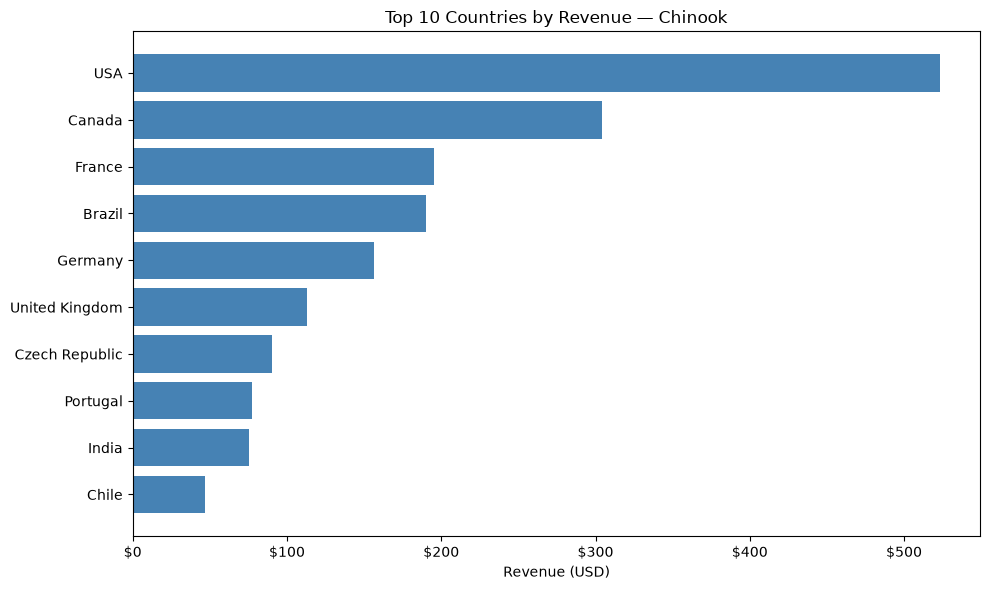

In [5]:
# --- Revenue by Country — Bar Chart ---

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(
    df_revenue["Country"][::-1],
    df_revenue["Revenue"][::-1],
    color="steelblue",
)
ax.set_xlabel("Revenue (USD)")
ax.set_title("Top 10 Countries by Revenue — Chinook")
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"${x:,.0f}")
)
plt.tight_layout()
plt.savefig("outputs/revenue_by_country.png", dpi=150)
plt.show()

## Query 3 — Top-Performing Sales Employee

Link `employees` to their assigned customers via `SupportRepId`,
then sum invoice totals to rank sales representatives.

In [6]:
# --- Q3: Top-Performing Sales Employee ---

q3 = """
    SELECT
        e.FirstName || ' ' || e.LastName AS Employee,
        e.Title,
        COUNT(DISTINCT c.CustomerId)     AS Customers,
        ROUND(SUM(i.Total), 2)           AS TotalSales
    FROM  Employee e
    JOIN  Customer c ON e.EmployeeId = c.SupportRepId
    JOIN  Invoice  i ON c.CustomerId = i.CustomerId
    GROUP BY e.EmployeeId
    ORDER BY TotalSales DESC;
"""

df_emp = pd.read_sql_query(q3, conn)
df_emp

,Employee,Title,Customers,TotalSales
0,Jane Peacock,Sales Support Agent,21,833.04
1,Margaret Park,Sales Support Agent,20,775.40
2,Steve Johnson,Sales Support Agent,18,720.16


## Findings

| Question | Answer |
|---|---|
| Best-selling track | See `df_tracks` above |
| Top revenue country | USA |
| Top sales employee | Jane Peacock |

Results reflect the full Chinook dataset
(invoices through December 2013).

In [7]:
# --- Cleanup ---

conn.close()
print("Connection closed.")

Connection closed.
